In [41]:
import numpy as np
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import pickle

from spectral.io import envi
from spectral.io.envi import read_envi_header

from scipy.signal import medfilt, savgol_filter
from scipy.interpolate import splrep, splev, interp1d

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.radiative_transfer.radiative_transfer import RadiativeTransfer
from isofit.radiative_transfer import luts
import logging

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

os.chdir('/store/carroll/col')

In [2]:
out_figs = 'figs/'

wl = np.loadtxt('data/wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('data/wl_nan.txt')

base_dir = 'data/test_rccs/'

# prepare representative single pxs
fp_single_px = 'data/2018/rccs/cal_tarp/single_pxs.pkl'
with open(fp_single_px, 'rb') as f:
    single_px_2018 = pickle.load(f)    
    
fp_single_px = 'data/2025/rccs/single_pxs.pkl'
with open(fp_single_px, 'rb') as f:
    single_px_2025 = pickle.load(f)

In [3]:
fids_2025 = [fid for fid in single_px_2025.keys() if any(x in fid for x in ('snodgrass', 'matterhorn'))]
bad = ['NIS01_20250627_155921_matterhorn_lot', 'NIS01_20250628_170927_snodgrass_busstop_insitu']
fids_2025 = [x for x in fids_2025 if x not in bad]
fids_2025

['NIS01_20250626_174116_snodgrass_busstop_insitu',
 'NIS01_20250628_165939_snodgrass_busstop_insitu',
 'NIS01_20250628_172359_snodgrass_busstop_insitu',
 'NIS01_20250628_174221_matterhorn_lot',
 'NIS01_20250629_150841_matterhorn_lot']

In [4]:
fids_2018 = [x for x in single_px_2018['rdn'].keys() if '20180611' in x]
fids_2018

['NIS01_20180611_172310',
 'NIS01_20180611_172711',
 'NIS01_20180611_173116',
 'NIS01_20180611_173537']

In [ ]:
# for each single px, get 3c, 6c rcc

# start with 2018 calibration tarps

In [5]:
# set up dict to hold outputs 

fids_year = {
    '2018': fids_2018,
    '2025': fids_2025,
}

targets_year = {
    '2018': ['white_tarp', 'black_tarp'],
    '2025': ['snodgrass', 'matterhorn'],
}

modeled_rdns = {
    emulator: {
        year: {
            target: {fid: [] for fid in fids_year[year]}
            for target in targets
        }
        for year, targets in targets_year.items()
    }
    for emulator in ['3c', '6c']
}

rccs = {
    emulator: {
        year: {
            target: {fid: [] for fid in fids_year[year]}
            for target in targets
        }
        for year, targets in targets_year.items()
    }
    for emulator in ['3c', '6c']
}

In [6]:
# 2018

targets = list(modeled_rdns['3c']['2018'].keys())

for fid in fids_2018:
    # load, update config file
    fp_configs = glob(os.path.join(base_dir, f'{fid}*', 'config', '*_isofit.json'))
    for fp in fp_configs:
        if '6c' in fp:
            emulator='6c'
        else:
            emulator='3c'
        print(fp, emulator)
        
        config = configs.create_new_config(fp)

        # set up forward model, io, inv according to config
        fm = ForwardModel(config) # loads pre-built LUT
        io = IO(config, fm)
        inv = Inversion(config, fm)
        
        for target in targets:
            print(target)
            try:
                # load the single pixel representation
                rdn_ = single_px_2018['rdn'][fid][target]
                obs_ = single_px_2018['obs'][fid][target]
                loc_ = single_px_2018['loc'][fid][target]
                geom = Geometry(obs=obs_, loc=loc_)         
        
                # run isofit per px
                states=inv.invert(rdn_, geom)
                x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
                x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, rdn_, geom)
        
                # get single px rcc
                fp_rfl = f'data/2018/insitu/cal_{target}_neon.txt'
                insitu_rfl = np.loadtxt(fp_rfl)[:,1]
                modeled_rdn = fm.calc_meas(np.concatenate([x_alg, x_RT, x_instrument]), geom, insitu_rfl)
                rcc_ = modeled_rdn/rdn_
               
                rccs[emulator]['2018'][target][fid] = rcc_
                modeled_rdns[emulator]['2018'][target][fid] = modeled_rdn
                
            except Exception as e:
                print(f"Error for flight {fid}, key {target}: {e}")

INFO:root:Loading config file: data/test_rccs/NIS01_20180611_172310/config/NIS01_20180611_172310_isofit.json
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20180611_172310/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


data/test_rccs/NIS01_20180611_172310/config/NIS01_20180611_172310_isofit.json 3c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


white_tarp


/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

data/test_rccs/NIS01_20180611_173537_6c/config/NIS01_20180611_173537_isofit.json 6c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


white_tarp


/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


black_tarp


In [17]:
# 2025

for fid in fids_2025:
    # define target
    if 'snodgrass' in fid:
        target = 'snodgrass'
        fp_rfl = f'data/2025/insitu/cal_snodgrass_bus_stop_neon.txt'
    elif 'matterhorn' in fid:
        target = 'matterhorn'
        fp_rfl = f'data/2025/insitu/cal_matterhorn_lot_neon.txt'
    
    # load, update config file
    fp_configs = glob(os.path.join(base_dir, f'{fid}*', 'config', '*_isofit.json'))
    for fp in fp_configs:
        if '6c' in fp:
            emulator='6c'
        else:
            emulator='3c'
        print(fp, emulator)
        
        config = configs.create_new_config(fp)

        # set up forward model, io, inv according to config
        fm = ForwardModel(config) # loads pre-built LUT
        io = IO(config, fm)
        inv = Inversion(config, fm)
        
        try:
            # load the single pixel representation
            rdn_ = single_px_2025[fid]['insitu']['rdn']
            obs_ = single_px_2025[fid]['insitu']['obs']
            loc_ = single_px_2025[fid]['insitu']['loc']
            geom = Geometry(obs=obs_, loc=loc_)         
    
            # run isofit per px
            states=inv.invert(rdn_, geom)
            x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
            x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, rdn_, geom)
    
            # get single px rcc
            insitu_rfl = np.loadtxt(fp_rfl)[:,1]
            modeled_rdn = fm.calc_meas(np.concatenate([x_alg, x_RT, x_instrument]), geom, insitu_rfl)
            rcc_ = modeled_rdn/rdn_
           
            rccs[emulator]['2025'][target][fid] = rcc_
            modeled_rdns[emulator]['2025'][target][fid] = modeled_rdn
            
        except Exception as e:
            print(f"Error for flight {fid}, key {target}: {e}")

INFO:root:Loading config file: data/test_rccs/NIS01_20250626_174116_snodgrass_busstop_insitu/config/NIS01_20250626_174116_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20250626_174116_snodgrass_busstop_insitu/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


data/test_rccs/NIS01_20250626_174116_snodgrass_busstop_insitu/config/NIS01_20250626_174116_isofit.json 3c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: data/test_rccs/NIS01_20250626_174116_snodgrass_busstop_insitu_6c/config/NIS01_20250626_174116_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20250626_174116_snodgrass_busstop_insitu_6c/data/wavelength

data/test_rccs/NIS01_20250626_174116_snodgrass_busstop_insitu_6c/config/NIS01_20250626_174116_isofit.json 6c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: data/test_rccs/NIS01_20250628_165939_snodgrass_busstop_insitu/config/NIS01_20250628_165939_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20250628_165939_snodgrass_busstop_insitu/data/wavelengths.txt


...

INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: data/test_rccs/NIS01_20250629_150841_matterhorn_lot/config/NIS01_20250629_150841_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20250629_150841_matterhorn_lot/data/wavelengths.txt
INFO:/store/carroll/

data/test_rccs/NIS01_20250629_150841_matterhorn_lot/config/NIS01_20250629_150841_isofit.json 3c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: data/test_rccs/NIS01_20250629_150841_matterhorn_lot_6c/config/NIS01_20250629_150841_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20250629_150841_matterhorn_lot_6c/data/wavelengths.txt
INFO:/store/ca

data/test_rccs/NIS01_20250629_150841_matterhorn_lot_6c/config/NIS01_20250629_150841_isofit.json 6c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


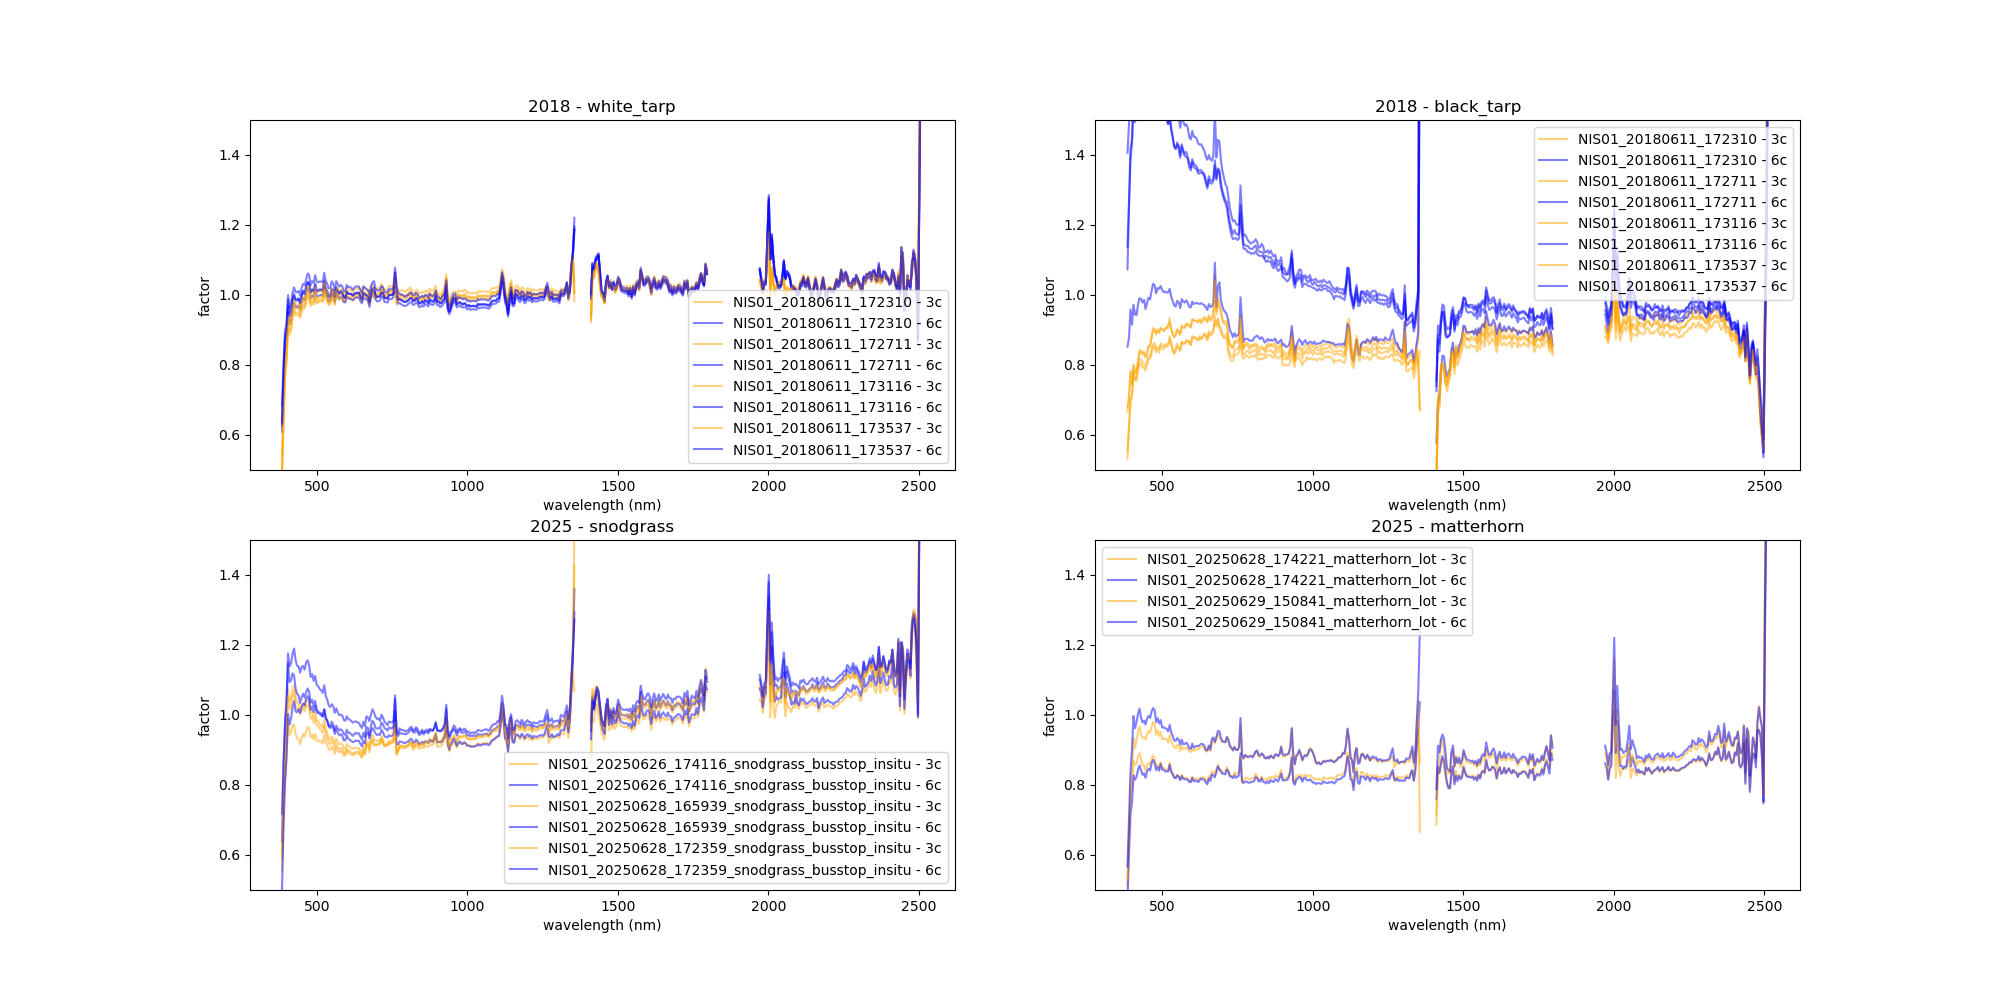

In [35]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20,10))

target = 'white_tarp'
for fid in fids_2018:
    for emulator in ['3c','6c']:
        rcc_ = rccs[emulator]['2018'][target][fid]
        if emulator=='3c':
            axs[0,0].plot(wl_nan, rcc_, color='orange', alpha=0.5, label=f'{fid} - {emulator}')
        elif emulator=='6c':
            axs[0,0].plot(wl_nan, rcc_, color='blue', alpha=0.5, label=f'{fid} - {emulator}')
    axs[0,0].set_title(f'2018 - {target}')

target = 'black_tarp'
for fid in fids_2018:
    for emulator in ['3c','6c']:
        rcc_ = rccs[emulator]['2018'][target][fid]
        if emulator=='3c':
            axs[0,1].plot(wl_nan, rcc_, color='orange', alpha=0.5, label=f'{fid} - {emulator}')
        elif emulator=='6c':
            axs[0,1].plot(wl_nan, rcc_, color='blue', alpha=0.5, label=f'{fid} - {emulator}')
    axs[0,1].set_title(f'2018 - {target}')

for fid in fids_2025:
    if 'snodgrass' in fid:
        target = 'snodgrass'
        ax=axs[1,0]
    elif 'matterhorn' in fid:
        target = 'matterhorn'
        ax=axs[1,1]
    for emulator in ['3c','6c']:
        rcc_ = rccs[emulator]['2025'][target][fid]
        if emulator=='3c':
            ax.plot(wl_nan, rcc_, color='orange', alpha=0.5, label=f'{fid} - {emulator}')
        elif emulator=='6c':
            ax.plot(wl_nan, rcc_, color='blue', alpha=0.5, label=f'{fid} - {emulator}')

    axs[1,0].set_title(f'2025 - snodgrass')
    axs[1,1].set_title(f'2025 - matterhorn')

for ax in axs.flat:
    ax.set_ylim(0.5, 1.5)
    ax.legend()
    ax.set_xlabel('wavelength (nm)')
    ax.set_ylabel('factor')

plt.show()

In [36]:
# export
fp_out = 'data/test_rccs/insitu_rccs_3c6c.pkl'
with open(fp_out, 'wb') as f:
    pickle.dump(rccs, f)

In [ ]:
# also visualize all of them detrended with the same exlusion zones
# what are the similarities, differences across targets, years?

/tmp/ipykernel_2567045/3481152027.py:57: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 5))


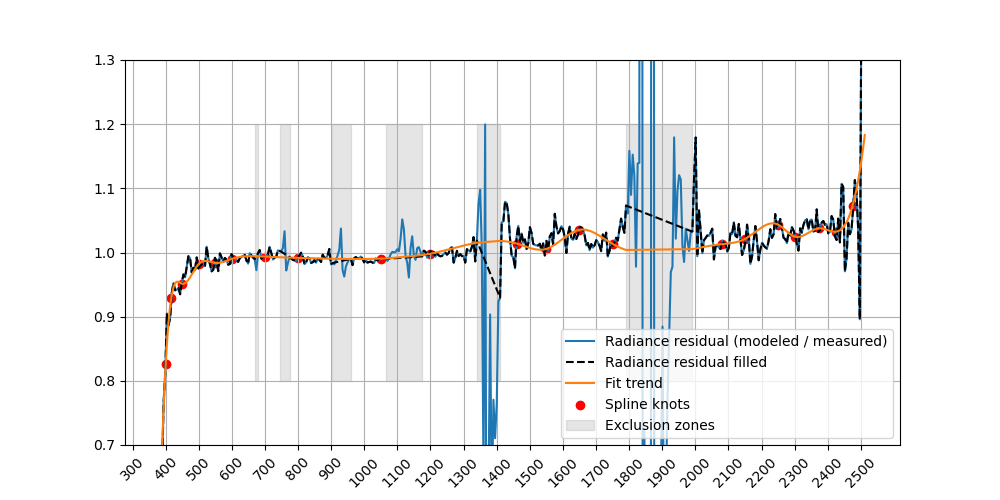

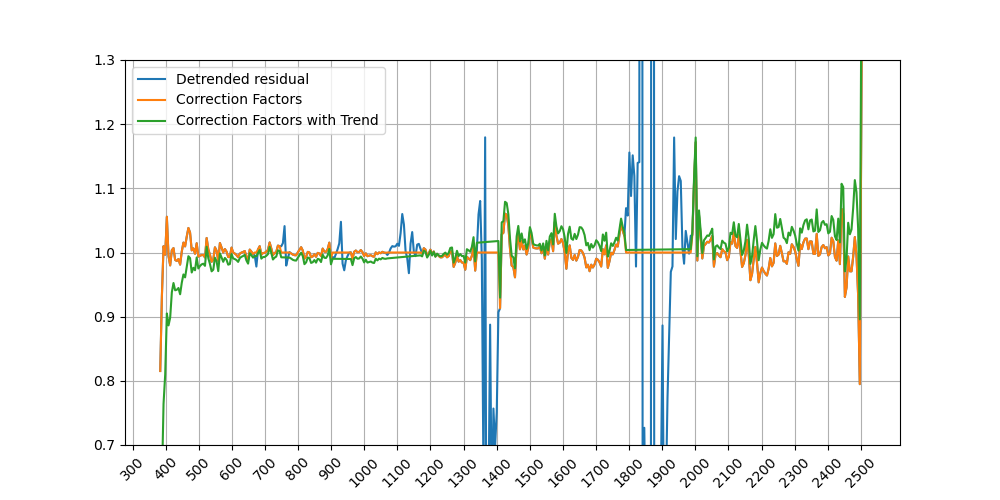

In [44]:
wl = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000
wl = wl/1000

def wl2ind(wl0):
    return np.argmin(np.abs(wl - wl0))

def ind2wl(ind0):
    return wl[ind0]

emulator = '3c'
year = '2018'
target = 'white_tarp'
fid = fids_2018[0]
radiance_ratio = rccs[emulator][year][target][fid]
radiance_ratio_adjusted = radiance_ratio.copy()

knots = np.array([400,417,450,500,550,600,700,800,1050,1200,1460,1550,1650,1750,2080,2150,2250,2300,2375,2425, 2475], dtype=np.float32)/1000.
ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.79, 1.99], # atm absorption regions (narrower)
                [0.669, 0.679]]
knot_average_window = 1

for a, b in ignore_zones:
    wl_subset = wl[np.logical_and(wl > a, wl < b)]
    radiance_ratio_adjusted[np.logical_and(wl > a, wl < b)] = interp1d([a,b],[radiance_ratio_adjusted[wl2ind(a)],radiance_ratio_adjusted[wl2ind(b)]])(wl_subset)

inds = np.array([wl2ind(q) for q in knots])
spline_y = np.array([np.mean(radiance_ratio_adjusted[x-knot_average_window:x+knot_average_window+1]) for x in inds])
spline = splrep(knots,spline_y)
y_trend  = splev(wl, spline)


y_detrend = radiance_ratio/y_trend
y_correction = radiance_ratio/y_trend
for ez in ignore_zones:
    y_correction[np.logical_and(wl > ez[0], wl < ez[1])] = 1
    y_trend[np.logical_and(wl > ez[0], wl < ez[1])] = interp1d([ez[0],ez[1]],[y_trend[wl2ind(ez[0])],y_trend[wl2ind(ez[1])]])(wl[np.logical_and(wl > ez[0], wl < ez[1])])


wl = wl*1000

plt.figure(figsize=(10, 5))
plt.plot(wl, radiance_ratio, label='Radiance residual (modeled / measured)')
plt.plot(wl, radiance_ratio_adjusted, label='Radiance residual filled', c='black',ls='--')
plt.plot(wl, y_trend, label='Fit trend')
plt.scatter(knots*1000, spline_y, color='r', label='Spline knots')
for _el, el in enumerate(ignore_zones):
    if _el == 0:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2, label='Exclusion zones')
    else:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2)

plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(wl, y_detrend, label='Detrended residual')
plt.plot(wl, y_correction, label='Correction Factors')
plt.plot(wl, y_correction*y_trend, label='Correction Factors with Trend')
plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

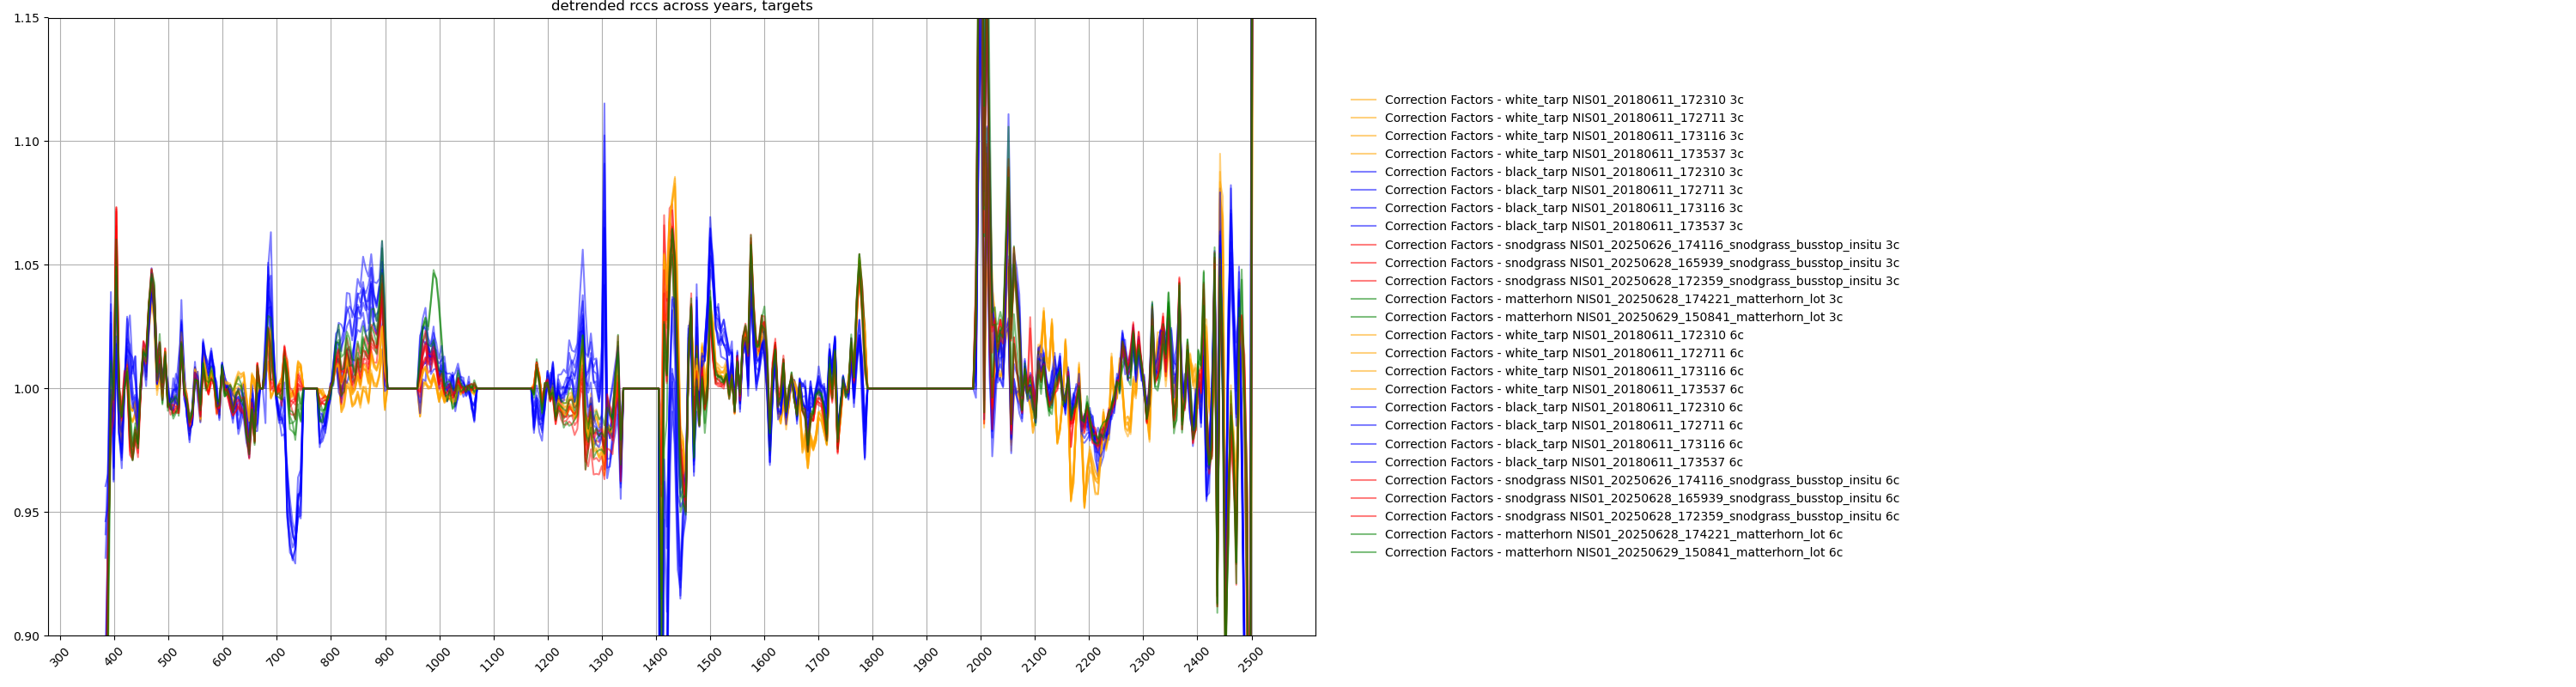

In [63]:
wl = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]

def wl2ind(wl0):
    return np.argmin(np.abs(wl - wl0))

def ind2wl(ind0):
    return wl[ind0]

knots = np.array([400,417,450,500,550,600,700,800,1050,1200,1460,1550,1650,1750,2080,2150,2250,2300,2375,2425, 2475], dtype=np.float32)/1000.
ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.79, 1.99], # atm absorption regions (narrower)
                [0.669, 0.679]]
knot_average_window = 1

fig = plt.figure(figsize=(30, 8))

for emulator in ['3c','6c']:
    for year in ['2018','2025']:
        for target in rccs[emulator][year].keys():
            for fid in rccs[emulator][year][target].keys():
                wl = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]
                try:
                    radiance_ratio = rccs[emulator][year][target][fid].copy()
                    radiance_ratio_adjusted = radiance_ratio.copy()
                    for a, b in ignore_zones:
                        wl_subset = wl[np.logical_and(wl > a, wl < b)]
                        radiance_ratio_adjusted[np.logical_and(wl > a, wl < b)] = interp1d([a,b],[radiance_ratio_adjusted[wl2ind(a)],radiance_ratio_adjusted[wl2ind(b)]])(wl_subset)
                    inds = np.array([wl2ind(q) for q in knots])
                    spline_y = np.array([np.mean(radiance_ratio_adjusted[x-knot_average_window:x+knot_average_window+1]) for x in inds])
                    spline = splrep(knots,spline_y)
                    y_trend  = splev(wl, spline)
                    
                    y_detrend = radiance_ratio/y_trend
                    y_correction = radiance_ratio/y_trend
                    for ez in ignore_zones:
                        y_correction[np.logical_and(wl > ez[0], wl < ez[1])] = 1
                        y_trend[np.logical_and(wl > ez[0], wl < ez[1])] = interp1d([ez[0],ez[1]],[y_trend[wl2ind(ez[0])],y_trend[wl2ind(ez[1])]])(wl[np.logical_and(wl > ez[0], wl < ez[1])])

                    if target=='white_tarp':
                        plt.plot(wl*1000, y_correction, label=f'Correction Factors - {target} {fid} {emulator}', color='orange', alpha=0.5)
                    elif target=='black_tarp':
                        plt.plot(wl*1000, y_correction, label=f'Correction Factors - {target} {fid} {emulator}', color='blue', alpha=0.5)
                    elif target=='snodgrass':
                        plt.plot(wl*1000, y_correction, label=f'Correction Factors - {target} {fid} {emulator}', color='red', alpha=0.5)   
                    elif target=='matterhorn':
                        plt.plot(wl*1000, y_correction, label=f'Correction Factors - {target} {fid} {emulator}', color='green', alpha=0.5)   
                        
                except: pass

plt.ylim([0.9, 1.15])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.75, 1])

plt.title('detrended rccs across years, targets')

plt.show()

plt.savefig(os.path.join(out_figs, 'all_detrended_rccs.png'), dpi=300, bbox_inches="tight")
